In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
df = pd.read_csv("input.csv")
df = df.dropna()
df

,drug1,drug2,drug3,dosage1,dosage2,dosage3,interaction_type,side_effect,stage
0,Ciprofloxacin,Insulin,Omeprazole,140,771,391,Moderate,Mild Allergic Reaction,1
1,Aspirin,Insulin,Azithromycin,161,235,625,Mild,Stroke,4
2,Insulin,Atorvastatin,Prednisolone,83,397,489,Severe,Dizziness,1
3,Doxycycline,Acetaminophen,Paracetamol,513,877,409,Mild,Stroke,4
4,Insulin,Metformin,Glipizide,61,358,952,Severe,Stomach Pain,1
...,...,...,...,...,...,...,...,...,...
241,Acetaminophen,Atorvastatin,Aspirin,266,819,257,Severe,Liver Enzyme Elevation,2
242,Omeprazole,Aspirin,Ibuprofen,181,146,879,Mild,Liver Enzyme Elevation,2
243,Warfarin,Prednisolone,Ciprofloxacin,112,331,448,Mild,Mild Kidney Issues,2
244,Paracetamol,Metformin,Amoxicillin,857,90,261,Severe,Breathing Difficulty,2


In [41]:
categorical_cols = ["drug1", "drug2", "drug3", "interaction_type", "side_effect", "stage"]
for col in categorical_cols:
    print(f"\nUnique values in {col}: {df[col].nunique()}")
    print(df[col].value_counts())


Unique values in drug1: 18
drug1
Amoxicillin      20
Aspirin          19
Ibuprofen        17
Ciprofloxacin    16
Doxycycline      16
Metformin        16
Omeprazole       16
Prednisolone     14
Insulin          13
Acetaminophen    13
Warfarin         12
Atorvastatin     12
Paracetamol      12
Metoprolol       12
Losartan         11
Glipizide        10
Azithromycin      9
Lisinopril        8
Name: count, dtype: int64

Unique values in drug2: 18
drug2
Atorvastatin     24
Metoprolol       23
Paracetamol      17
Metformin        16
Glipizide        15
Ciprofloxacin    15
Ibuprofen        15
Prednisolone     15
Lisinopril       14
Insulin          13
Doxycycline      12
Warfarin         11
Omeprazole       11
Losartan         10
Amoxicillin       9
Azithromycin      9
Acetaminophen     9
Aspirin           8
Name: count, dtype: int64

Unique values in drug3: 18
drug3
Warfarin         21
Lisinopril       20
Aspirin          20
Azithromycin     19
Omeprazole       17
Losartan         17
Parace

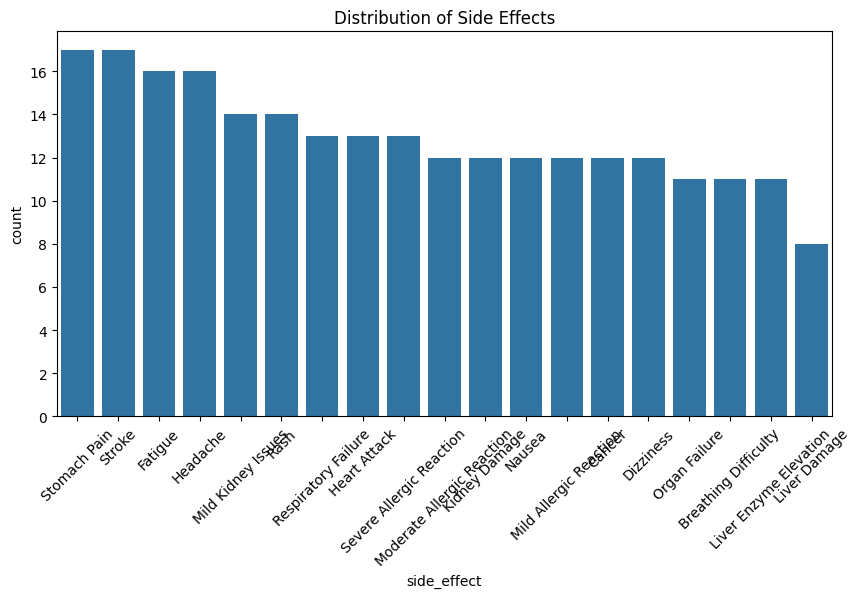

In [42]:
plt.figure(figsize=(10, 5))
sns.countplot(x="side_effect", data=df, order=df["side_effect"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Side Effects")
plt.show()

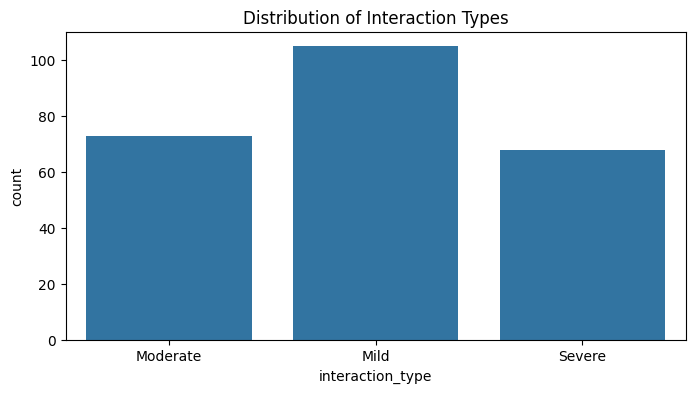

In [43]:
plt.figure(figsize=(8, 4))
sns.countplot(x="interaction_type", data=df)
plt.title("Distribution of Interaction Types")
plt.show()


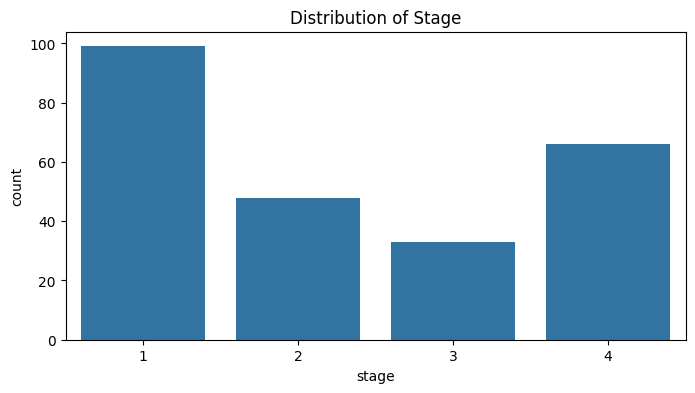

In [44]:
plt.figure(figsize=(8, 4))
sns.countplot(x="stage", data=df)
plt.title("Distribution of Stage")
plt.show()

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [46]:
X = df[["drug1", "drug2", "drug3", "dosage1", "dosage2", "dosage3"]]
y = df["interaction_type"]
import pickle
# Encode categorical variables
label_encoders = {}
for col in ["drug1", "drug2", "drug3"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))
with open("feature.pkl", "wb") as f:
        pickle.dump(label_encoders, f)

# Encode target variable
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)
with open("interaction_type_encode.pkl", "wb") as f:
        pickle.dump(dict(zip(y_encoder.classes_, y_encoder.transform(y_encoder.classes_))), f)


C:\Users\dell\AppData\Local\Temp\ipykernel_2528\3921903846.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\dell\AppData\Local\Temp\ipykernel_2528\3921903846.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\dell\AppData\Local\Temp\ipykernel_2528\3921903846.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [47]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)


RandomForestClassifier(random_state=42)

In [48]:
with open("randomforestmodelinteraction_type.pkl", "wb") as f:
        pickle.dump(rf_model, f)

In [49]:
df = pd.read_csv("test.csv")
for col in ["drug1", "drug2", "drug3"]:
    df[col] = df[col].map(label_encoders[col])
#df = df.dropna()
df.fillna(0, inplace=True)
ytest = df["interaction_type"]
ytest=ytest.map(dict(zip(y_encoder.classes_, y_encoder.transform(y_encoder.classes_))))  
Xtest = df[["drug1", "drug2", "drug3", "dosage1", "dosage2", "dosage3"]]

In [50]:
Xtest

,drug1,drug2,drug3,dosage1,dosage2,dosage3
0,6,15,13,990,990,715
1,13,16,2,525,748,537
2,9,13,2,110,206,673
3,8,14,7,80,130,368
4,6,15,13,990,990,715
...,...,...,...,...,...,...
112,0,3,2,266,819,257
113,14,2,8,181,146,879
114,17,16,5,112,331,448
115,15,12,1,857,90,261


In [51]:
y_pred = rf_model.predict(Xtest)

In [52]:
accuracy = accuracy_score(ytest, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.97


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(ytest, y_pred)
precision = precision_score(ytest, y_pred, average='weighted')
recall = recall_score(ytest, y_pred, average='weighted')
f1 = f1_score(ytest, y_pred, average='weighted')
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9658119658119658
Precision: 0.9660425993759326
Recall: 0.9658119658119658
F1 Score: 0.9658119658119658


In [54]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

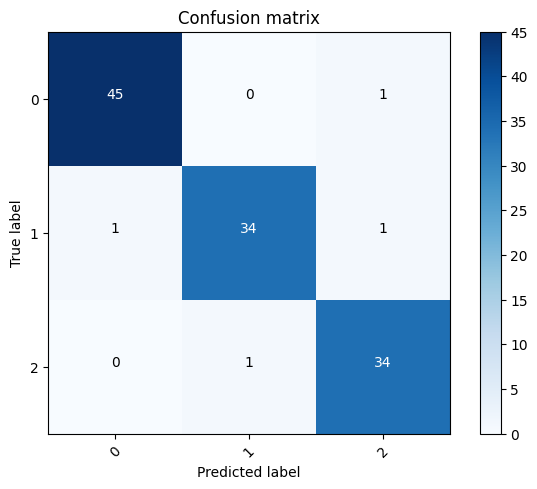

In [55]:
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.metrics import confusion_matrix
import itertools
import numpy as np
# compute the confusion matrix
confusion_mtx = confusion_matrix(ytest, y_pred) 

plot_confusion_matrix(confusion_mtx, classes = range(3))